In [ ]:
!pip install qiskit ipywidgets
!pip install pylatexenc

In [ ]:
import qiskit
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import GroverOperator
!pip install qiskit_aer
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_distribution
from math import pi
from qiskit_aer import noise
from qiskit.result import marginal_counts



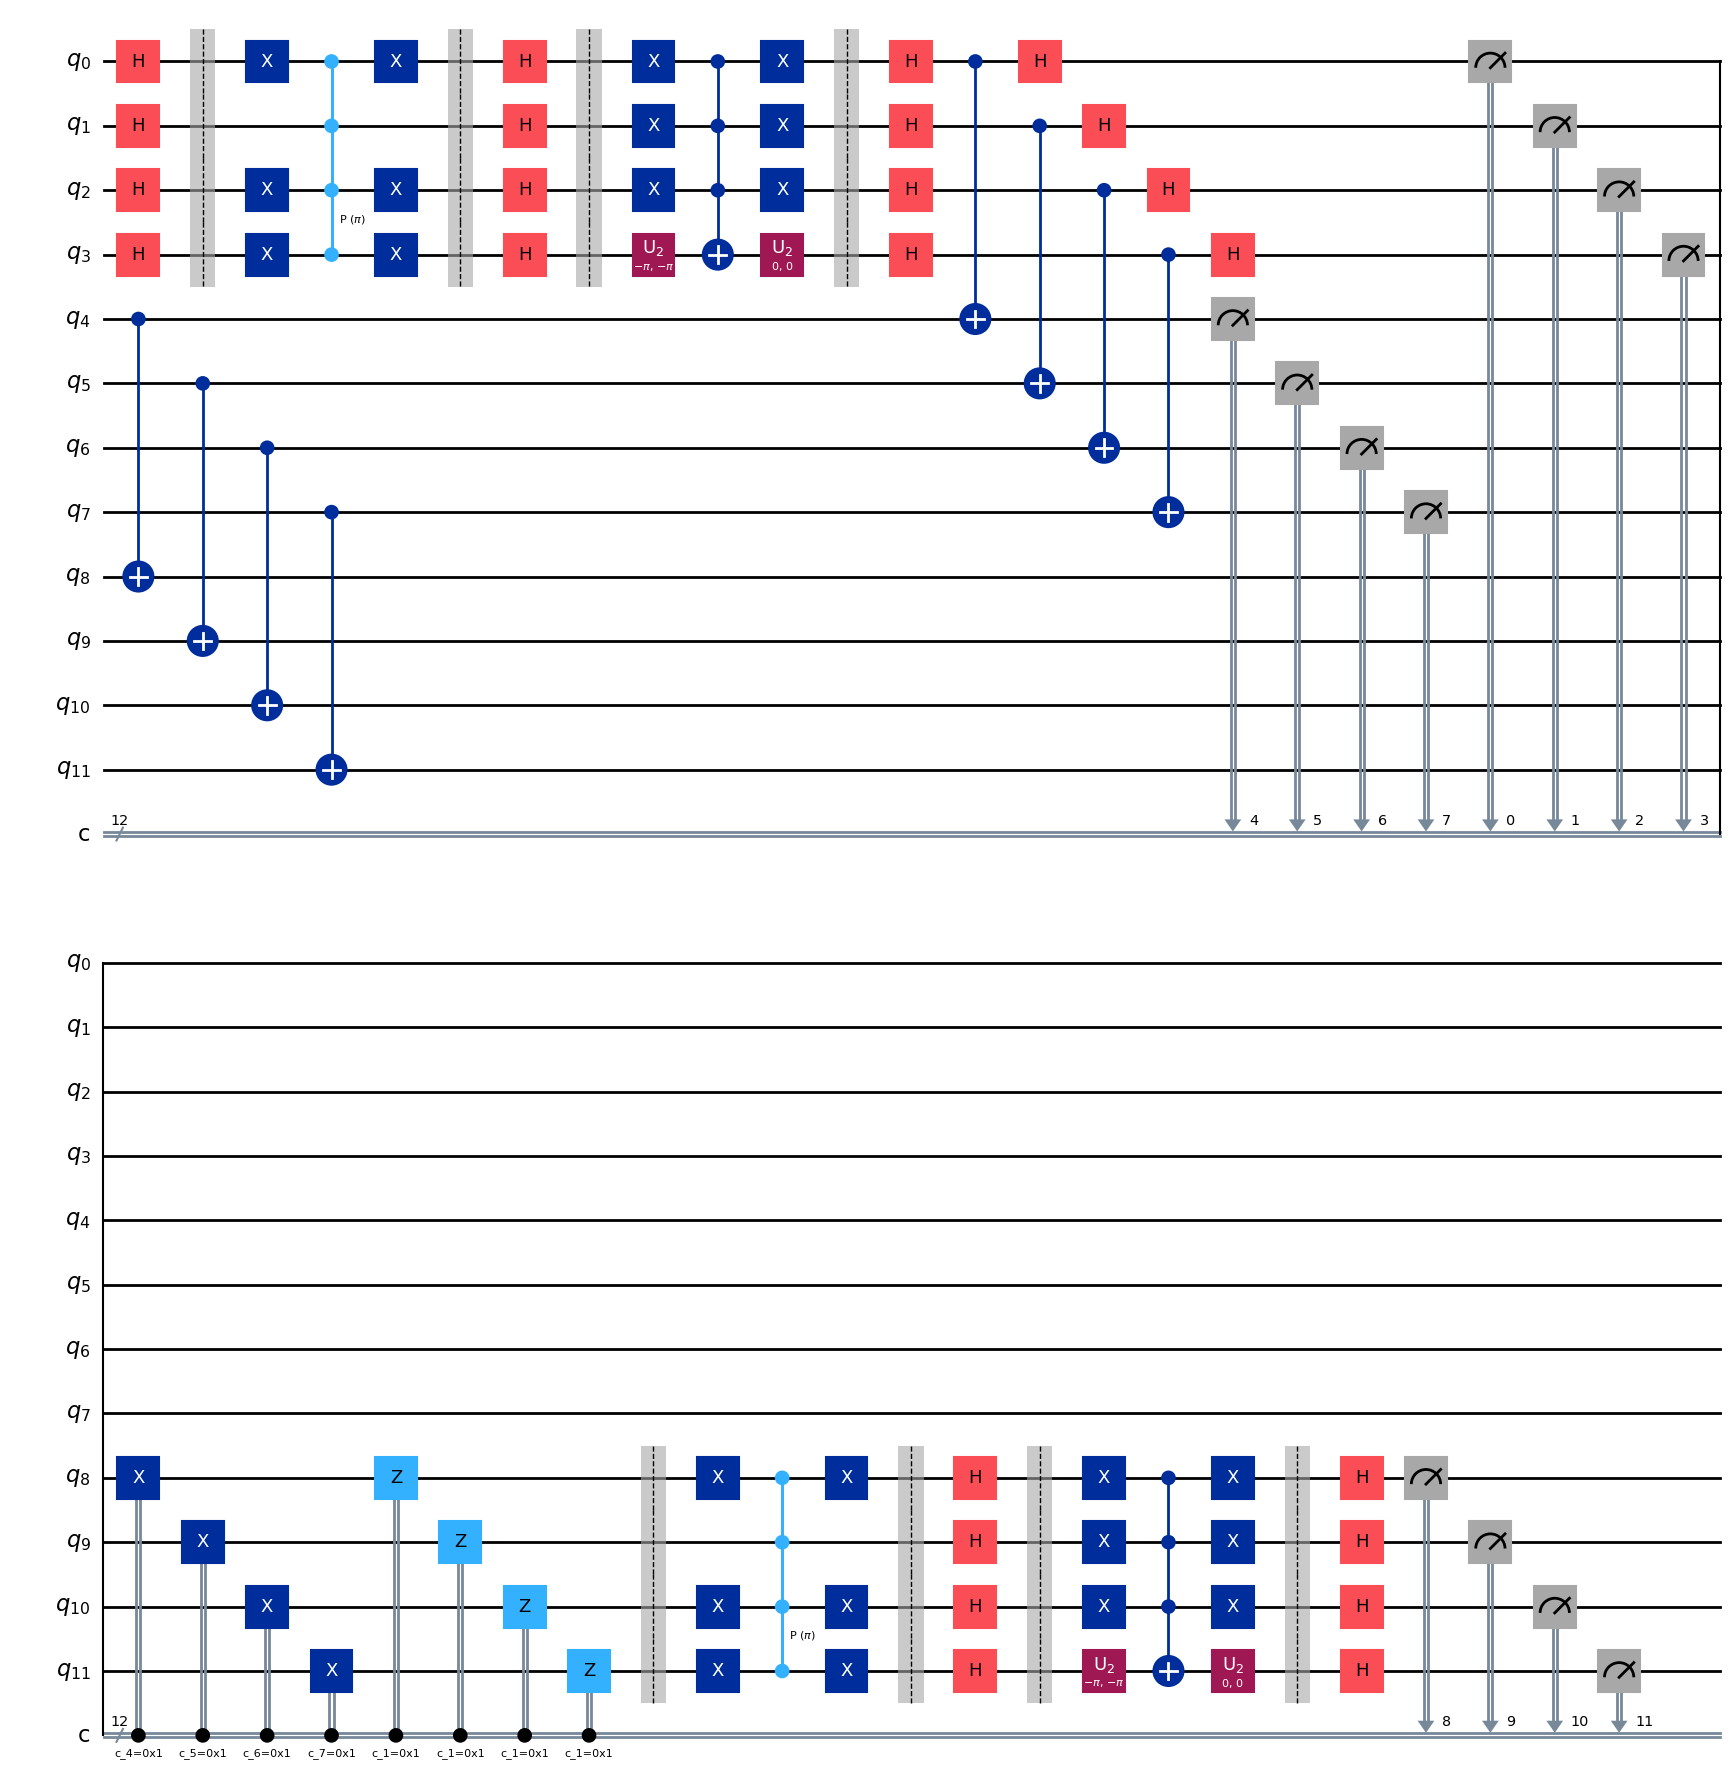

In [ ]:
qc = QuantumCircuit(12, 12)
qc.h(range(4))
qc.barrier(range(4))
mark_state = QuantumCircuit(4)
mark_state.x([0, 2, 3])
mark_state.mcp(pi, list(range(3)), 3)
mark_state.x([0, 2, 3])


grover_op = GroverOperator( mark_state, insert_barriers=True)
qc.append(grover_op, range(4))
#qc.draw('mpl')
simulator_aer = AerSimulator(seed_simulator = 2)
qc = transpile(qc, backend=simulator_aer)

qc.cx(4, 8)
qc.cx(5, 9)
qc.cx(6, 10)
qc.cx(7, 11)

qc.cx(0, 4)
qc.h(0)
qc.cx(1, 5)
qc.h(1)
qc.cx(2, 6)
qc.h(2)
qc.cx(3, 7)
qc.h(3)

for i in range(4, 8):
  qc.measure(i, i)
for i in range (0, 4):
  qc.measure(i, i)
for i in range (4, 8):
  qc.x(i+4).c_if(i, 1)
for i in range (4, 8):
  qc.z(i+4).c_if(i, 1)

qc.barrier([8, 9, 10, 11])
qc.append(grover_op, [8, 9, 10, 11])
simulator_aer = AerSimulator(seed_simulator = 42)
qc = transpile(qc, backend = simulator_aer)

for i in range(8, 12):
  qc.measure(i, i)
qc.draw('mpl')

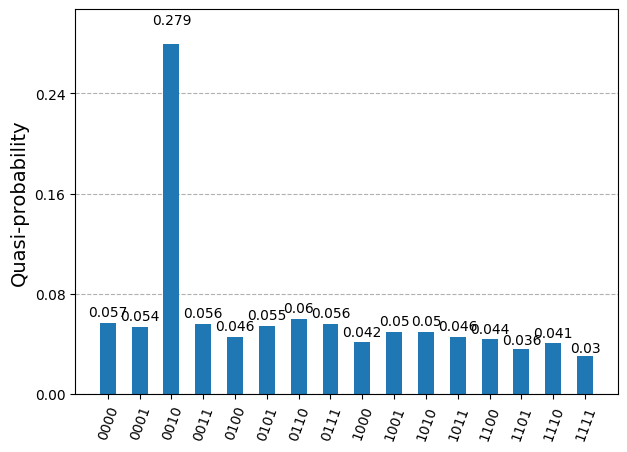

In [ ]:
qc = transpile(qc, backend = simulator_aer)

error1 = noise.depolarizing_error(0.001, 1)
error2 = noise.depolarizing_error (0.01, 2)
error3 = noise.depolarizing_error (0.1, 3)

noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error (error1, ['h', 'u2', 'x', 'z'])
noise_model.add_all_qubit_quantum_error (error2, ['cx'])
noise_model.add_all_qubit_quantum_error (error3, ['mcp', 'mcx'])

basic_gates = noise_model.basis_gates

result_noisy = simulator_aer.run(qc, shots=1024, noise_model = noise_model, basis_gate = basic_gates).result()
counts = result_noisy.get_counts()
marginal_result = marginal_counts(counts, indices = [11, 10, 9, 8])
plot_distribution(marginal_result)